In [1]:
import h5py
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F

class CERNJetUnlabelledDataset(Dataset):
    def __init__(self, file_path, transform=None):
        """
        Args:
            file_path (string): Path to the .h5 file.
            transform (callable, optional): Optional transform to be applied on a sample.
        """
        self.file_path = file_path
        self.transform = transform
        self.dataset = None
        self.h5_file = None
        
        # Open briefly just to get the dataset length and keys
        with h5py.File(self.file_path, 'r') as f:
            self.keys = list(f.keys())
            print(f"Detected keys in .h5 file: {self.keys}")
            
            # Assuming the primary data is under the first key (e.g., 'X', 'data', or 'jets')
            # You may need to change self.keys[0] to the exact string name if there are multiple keys.
            self.data_key = self.keys[0] 
            self.length = len(f[self.data_key])

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        # Multiprocessing safeguard: Open the file ONLY if a worker doesn't have it open yet
        if self.h5_file is None:
            self.h5_file = h5py.File(self.file_path, 'r')
            self.dataset = self.h5_file[self.data_key]

        # Read the specific image array at this index
        img = self.dataset[idx] 
        
        # Convert to a PyTorch FloatTensor
        img = torch.tensor(img, dtype=torch.float32)

        # PyTorch expects channels first: (Channels, Height, Width)
        # If the data comes in as (125, 125, 8), we permute it to (8, 125, 125)
        if img.shape[-1] == 8:
            img = img.permute(2, 0, 1)

        img = torch.log1p(img)

        # --- The Crucial XCiT Padding Step ---
        # Pad from 125x125 to 128x128 so it divides cleanly by patch_size 8 or 16
        # F.pad format for 2D is (pad_left, pad_right, pad_top, pad_bottom)
        # We add 1 pixel left/top, and 2 pixels right/bottom (1+2=3 pixels total)
        img = F.pad(img, (1, 2, 1, 2), mode='constant', value=0.0)

        # Apply any normalizations if provided
        if self.transform:
            img = self.transform(img)

        return img

    def __del__(self):
        # Clean up the file handle when the dataset is destroyed
        if self.h5_file is not None:
            self.h5_file.close()

In [2]:
# Assuming standard Kaggle/Colab input path structure
DATA_PATH = '/kaggle/input/datasets/happysaxena/cern-unlabelled-data/Dataset_Specific_Unlabelled.h5'
# If the path is relative to your working directory, just use the folder name:
# DATA_PATH = 'cern_unlabelled_data/Dataset_Specific_Unlabelled.h5'

# Initialize Dataset
unlabelled_dataset = CERNJetUnlabelledDataset(file_path=DATA_PATH)

# Initialize Dataloader
# batch_size=64 is a good starting point for XCiT if you have a T4 or P100 GPU
train_loader = DataLoader(
    unlabelled_dataset, 
    batch_size=64, 
    shuffle=True, 
    num_workers=2, # Set to 2 or 4 for faster loading
    pin_memory=True # Speeds up transfer to GPU
)

# Test it out to verify shapes
for batch in train_loader:
    print(f"Batch shape: {batch.shape}") # Should print: torch.Size([64, 8, 128, 128])
    break

Detected keys in .h5 file: ['jet']
Batch shape: torch.Size([64, 8, 128, 128])


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# --- UTILITIES ---
def to_2tuple(x):
    return x if isinstance(x, tuple) else (x, x)

class DropPath(nn.Module):
    """Stochastic Depth (DropPath) implementation to avoid `timm` dependency."""
    def __init__(self, drop_prob=0.):
        super().__init__()
        self.drop_prob = drop_prob

    def forward(self, x):
        if self.drop_prob == 0. or not self.training:
            return x
        keep_prob = 1 - self.drop_prob
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)
        random_tensor = keep_prob + torch.rand(shape, dtype=x.dtype, device=x.device)
        random_tensor.floor_()  # binarize
        return x.div(keep_prob) * random_tensor

class Mlp(nn.Module):
    """Standard Feed-Forward Network"""
    def __init__(self, in_features, hidden_features=None, out_features=None, act_layer=nn.GELU):
        super().__init__()
        hidden_features = hidden_features or in_features
        out_features = out_features or in_features
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.act = act_layer()
        self.fc2 = nn.Linear(hidden_features, out_features)

    def forward(self, x):
        return self.fc2(self.act(self.fc1(x)))

class CPE(nn.Module):
    """Conditional Positional Encoding using a 3x3 depthwise convolution."""
    def __init__(self, dim, k=3):
        super().__init__()
        self.proj = nn.Conv2d(dim, dim, kernel_size=k, stride=1, padding=k//2, groups=dim)

    def forward(self, x, size):
        B, N, C = x.shape
        H, W = size
        # Reshape to 2D image format (B, C, H, W)
        feat = x.transpose(1, 2).contiguous().view(B, C, H, W)
        feat = self.proj(feat)
        # Flatten back to sequence (B, N, C)
        feat = feat.flatten(2).transpose(1, 2)
        return x + feat

# --- TEST STEP 1 ---
if __name__ == "__main__":
    dummy_x = torch.randn(2, 3136, 96) # Batch=2, Seq=3136 (56x56), Dim=96
    cpe = CPE(dim=96)
    out = cpe(dummy_x, size=(56, 56))
    print("Step 1 (CPE) Output Shape:", out.shape) # Expected: [2, 3136, 96]

Step 1 (CPE) Output Shape: torch.Size([2, 3136, 96])


In [4]:
class ConvStem(nn.Module):
    """Initial Convolutional Stem: Downsamples image by 4x."""
    def __init__(self, in_chans, embed_dim):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Conv2d(in_chans, embed_dim // 2, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(embed_dim // 2),
            nn.ReLU(),
            nn.Conv2d(embed_dim // 2, embed_dim, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(embed_dim),
        )

    def forward(self, x):
        return self.proj(x)

class PatchEmbed(nn.Module):
    """Acts as the Stem (Stage 0) or Downsampler (Stages 1, 2, 3)."""
    def __init__(self, patch_size=16, in_chans=3, embed_dim=96, is_stem=False):
        super().__init__()
        self.patch_size = to_2tuple(patch_size)
        self.is_stem = is_stem
        
        if self.is_stem: # Stage 0
            self.proj = ConvStem(in_chans, embed_dim)
            self.norm = nn.LayerNorm(embed_dim)
        else: # Patch Merging between stages
            self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=2, stride=2)
            self.norm = nn.LayerNorm(in_chans)

    def forward(self, x, size=None):
        if len(x.shape) == 3: # If input is a sequence (B, L, C)
            B, HW, C = x.shape
            H, W = size
            x = self.norm(x)
            x = x.reshape(B, H, W, C).permute(0, 3, 1, 2).contiguous()

        x = self.proj(x)
        newsize = (x.size(2), x.size(3))
        x = x.flatten(2).transpose(1, 2)
        
        if self.is_stem:
            x = self.norm(x)
        return x, newsize

# --- TEST STEP 2 ---
if __name__ == "__main__":
    dummy_img = torch.randn(2, 3, 224, 224) # Standard 224x224 image
    stem = PatchEmbed(patch_size=4, in_chans=3, embed_dim=96, is_stem=True)
    out, newsize = stem(dummy_img)
    print(f"Step 2 (Stem) Output Shape: {out.shape}, New Grid Size: {newsize}") 
    # Expected: [2, 3136, 96], Size: (56, 56)

Step 2 (Stem) Output Shape: torch.Size([2, 3136, 96]), New Grid Size: (56, 56)


In [5]:
def window_partition(x, window_size: int):
    B, H, W, C = x.shape
    x = x.view(B, H // window_size, window_size, W // window_size, window_size, C)
    windows = x.permute(0, 1, 3, 2, 4, 5).contiguous().view(-1, window_size, window_size, C)
    return windows

def window_reverse(windows, window_size: int, H: int, W: int):
    B = int(windows.shape[0] / (H * W / window_size / window_size))
    x = windows.view(B, H // window_size, W // window_size, window_size, window_size, -1)
    x = x.permute(0, 1, 3, 2, 4, 5).contiguous().view(B, H, W, -1)
    return x

class WindowAttention(nn.Module):
    """Standard Self-Attention restricted to local windows."""
    def __init__(self, dim, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.scale = (dim // num_heads) ** -0.5
        self.qkv = nn.Linear(dim, dim * 3)
        self.proj = nn.Linear(dim, dim)

    def forward(self, x):
        B_, N, C = x.shape
        qkv = self.qkv(x).reshape(B_, N, 3, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]

        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        
        x = (attn @ v).transpose(1, 2).reshape(B_, N, C)
        return self.proj(x)

class LWABlock(nn.Module):
    """Local Window Attention Block"""
    def __init__(self, dim, num_heads, window_size=7, mlp_ratio=4., drop_path=0.):
        super().__init__()
        self.dim = dim
        self.window_size = window_size
        self.cpe = nn.ModuleList([CPE(dim), CPE(dim)])
        self.norm1 = nn.LayerNorm(dim)
        self.attn = WindowAttention(dim, num_heads)
        self.drop_path = DropPath(drop_path)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = Mlp(in_features=dim, hidden_features=int(dim * mlp_ratio))

    def forward(self, x, size):
        H, W = size
        B, L, C = x.shape

        shortcut = self.cpe[0](x, size)
        x = self.norm1(shortcut).view(B, H, W, C)

        # Pad feature maps if they aren't divisible by window_size
        pad_r = (self.window_size - W % self.window_size) % self.window_size
        pad_b = (self.window_size - H % self.window_size) % self.window_size
        x = F.pad(x, (0, 0, 0, pad_r, 0, pad_b))
        _, Hp, Wp, _ = x.shape

        # Partition -> Attend -> Reverse
        x_windows = window_partition(x, self.window_size).view(-1, self.window_size**2, C)
        attn_windows = self.attn(x_windows)
        attn_windows = attn_windows.view(-1, self.window_size, self.window_size, C)
        x = window_reverse(attn_windows, self.window_size, Hp, Wp)

        # Remove padding
        if pad_r > 0 or pad_b > 0:
            x = x[:, :H, :W, :].contiguous()

        x = shortcut + self.drop_path(x.view(B, H * W, C))
        
        # FFN Part
        x = self.cpe[1](x, size)
        x = x + self.drop_path(self.mlp(self.norm2(x)))
        return x, size

# --- TEST STEP 3 ---
if __name__ == "__main__":
    lwa = LWABlock(dim=96, num_heads=3)
    out, _ = lwa(out, newsize) # Uses outputs from Step 2
    print("Step 3 (LWA Block) Output Shape:", out.shape) # Expected: [2, 3136, 96]

Step 3 (LWA Block) Output Shape: torch.Size([2, 3136, 96])


In [6]:
class LinearAttention(nn.Module):
    """O(N) Complexity Attention mechanism"""
    def __init__(self, dim, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.scale = (dim // num_heads) ** -0.5
        self.qkv = nn.Linear(dim, dim * 3)
        self.proj = nn.Linear(dim, dim)
        self.act = nn.ReLU()
        # Learnable temperature to replace Softmax normalization effect
        self.temperature = nn.Parameter(torch.ones(num_heads, 1, 1) * self.scale)

    def forward(self, x):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]

        # ReLU mapping ensures non-negativity (crucial for Linear Attention)
        q = self.act(q)
        k = self.act(k)
        
        # Calculate K^T * V first! (This is where O(N^2) becomes O(N))
        kv = (k.transpose(-2, -1) @ v) * self.temperature
        
        # Calculate denominator and clamp to prevent dividing by zero
        k_sum = k.transpose(-2, -1).sum(dim=-1, keepdim=True)
        denom = torch.clamp(q @ k_sum, min=1e-2)

        attn = (q @ kv) / denom
        
        x = attn.transpose(1, 2).reshape(B, N, C)
        return self.proj(x)

class LCM(nn.Module):
    """Local Concentration Module: Refocuses linear attention locally."""
    def __init__(self, dim, kernel_size=7):
        super().__init__()
        pad = kernel_size // 2
        self.conv1 = nn.Conv2d(dim, dim, kernel_size=kernel_size, padding=pad, groups=dim)
        self.act = nn.GELU()
        self.bn = nn.BatchNorm2d(dim)
        self.conv2 = nn.Conv2d(dim, dim, kernel_size=kernel_size, padding=pad, groups=dim)

    def forward(self, x, size):
        B, N, C = x.shape
        H, W = size
        x = x.transpose(-1, -2).contiguous().view(B, C, H, W)
        x = self.conv2(self.bn(self.act(self.conv1(x))))
        return x.flatten(2).transpose(-1, -2)

class LGABlock(nn.Module):
    """Linear Global Attention Block"""
    def __init__(self, dim, num_heads, mlp_ratio=4., drop_path=0.):
        super().__init__()
        self.cpe = nn.ModuleList([CPE(dim)])
        self.norm1 = nn.LayerNorm(dim)
        self.attn = LinearAttention(dim, num_heads)
        self.drop_path = DropPath(drop_path)
        
        self.norm3 = nn.LayerNorm(dim)
        self.local_mp = LCM(dim)
        
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = Mlp(in_features=dim, hidden_features=int(dim * mlp_ratio))

    def forward(self, x, size):
        # 1. CPE & Linear Attn
        x = self.cpe[0](x, size)
        cur = self.attn(self.norm1(x))
        x = x + self.drop_path(cur)
        
        # 2. LCM
        x = x + self.drop_path(self.local_mp(self.norm3(x), size))
        
        # 3. FFN
        x = x + self.drop_path(self.mlp(self.norm2(x)))
        return x, size

# --- TEST STEP 4 ---
if __name__ == "__main__":
    lga = LGABlock(dim=96, num_heads=3)
    out, _ = lga(out, newsize)
    print("Step 4 (LGA Block) Output Shape:", out.shape) # Expected: [2, 3136, 96]

Step 4 (LGA Block) Output Shape: torch.Size([2, 3136, 96])


In [7]:

import torch
import torch.nn as nn

class L2ViT_Tiny_CERN(nn.Module):
    """L2ViT-Tiny adapted for CERN Task 2h: 
       Simultaneous Classification + Mass Regression (+ optional Momentum Regression)
    """
    def __init__(self, in_chans=3, num_classes=2, drop_path_rate=0.1, include_momentum=False):
        super().__init__()
        self.include_momentum = include_momentum
        
        # L2ViT-Tiny Configurations
        depths = [2, 2, 6, 2]
        dims =[96, 192, 384, 768]
        num_heads =[3, 6, 12, 24]
        
        # 1. Patch Embeddings (Downsampling layers)
        self.downsample_layers = nn.ModuleList()
        for i in range(4):
            embed = PatchEmbed(
                patch_size=4 if i == 0 else 2,
                in_chans=in_chans if i == 0 else dims[i - 1],
                embed_dim=dims[i],
                is_stem=(i == 0)
            )
            self.downsample_layers.append(embed)

        # 2. Transformer Stages
        self.stages = nn.ModuleList()
        dp_rates =[x.item() for x in torch.linspace(0, drop_path_rate, sum(depths))] 
        cur = 0
        
        for i in range(4):
            blocks =[]
            for j in range(depths[i]):
                # Alternating LWA and LGA blocks
                if j % 2 == 0:
                    blocks.append(LWABlock(dims[i], num_heads[i], drop_path=dp_rates[cur + j]))
                else:
                    blocks.append(LGABlock(dims[i], num_heads[i], drop_path=dp_rates[cur + j]))
            self.stages.append(nn.ModuleList(blocks))
            cur += depths[i]

        # 3. Final Norm and Global Average Pooling
        self.norm = nn.LayerNorm(dims[-1])
        self.avgpool = nn.AdaptiveAvgPool1d(1)

        # 4. Task 2h Specific Heads
        # Base tasks: Classification and Mass Regression
        self.cls_head = nn.Linear(dims[-1], num_classes) # Particle ID
        self.mass_head = nn.Linear(dims[-1], 1)          # Mass Regression
        
        # Optional task: Momentum Regression
        if self.include_momentum:
            self.mom_head = nn.Linear(dims[-1], 1)   
            
    # Momentum Regression
    def forward_features(self, x):
        size = [x.size(2), x.size(3)]
        for i in range(4):
            x, size = self.downsample_layers[i](x, size)
            for block in self.stages[i]:
                x, size = block(x, size)
        x = self.norm(x)
        B, N, C = x.shape
        H, W = size
        return x.transpose(1, 2).view(B, C, H, W)

    def forward(self, x):
        size =[x.size(2), x.size(3)]
        
        # Pass through the 4 hierarchical stages
        for i in range(4):
            x, size = self.downsample_layers[i](x, size)
            for block in self.stages[i]:
                x, size = block(x, size)
                
        # Aggregate global features
        x = self.norm(x)
        x = self.avgpool(x.transpose(1, 2)).flatten(1) # Final shape: (Batch, 768)
        
        # Base Output Dictionary
        outputs = {
            'class_logits': self.cls_head(x),
            'mass_pred': self.mass_head(x)
        }
        
        # Add momentum prediction if the head was initialized
        if self.include_momentum:
            outputs['mom_pred'] = self.mom_head(x)
            
        return outputs

# --- TEST FINAL FLOW ---
if __name__ == "__main__":
    print("\n--- FINAL MODEL VALIDATION ---")
    
    # Random batch of Images (Batch=4, Channels=3, H=224, W=224)
    # Note: Check your .h5 file for the exact number of channels the CERN data uses!
    dummy_input = torch.randn(4, 3, 224, 224)
    
    print("\nTest 1: Strategy A (Classification + Mass only)")
    model_A = L2ViT_Tiny_CERN(in_chans=3, num_classes=2, include_momentum=False)
    outputs_A = model_A(dummy_input)
    print("Keys in output:", outputs_A.keys())
    print("Class Output Shape:", outputs_A['class_logits'].shape) # Expected:[4, 2]
    print("Mass Output Shape:", outputs_A['mass_pred'].shape)     # Expected: [4, 1]
    
    print("\nTest 2: Strategy B (Classification + Mass + Momentum)")
    model_B = L2ViT_Tiny_CERN(in_chans=3, num_classes=2, include_momentum=True)
    outputs_B = model_B(dummy_input)
    print("Keys in output:", outputs_B.keys())
    print("Class Output Shape:", outputs_B['class_logits'].shape) # Expected: [4, 2]
    print("Mass Output Shape:", outputs_B['mass_pred'].shape)     # Expected:[4, 1]
    print("Mom Output Shape:", outputs_B['mom_pred'].shape)       # Expected:[4, 1]
    print("\nForward Pass Successful for both strategies!")


--- FINAL MODEL VALIDATION ---

Test 1: Strategy A (Classification + Mass only)
Keys in output: dict_keys(['class_logits', 'mass_pred'])
Class Output Shape: torch.Size([4, 2])
Mass Output Shape: torch.Size([4, 1])

Test 2: Strategy B (Classification + Mass + Momentum)
Keys in output: dict_keys(['class_logits', 'mass_pred', 'mom_pred'])
Class Output Shape: torch.Size([4, 2])
Mass Output Shape: torch.Size([4, 1])
Mom Output Shape: torch.Size([4, 1])

Forward Pass Successful for both strategies!


Using device: cuda
Initializing L2ViT Pretraining on cuda for 50 epochs...


Epoch 1/50:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 1/50 Completed | Avg Loss: 0.1143 | LR: 0.000999


Epoch 2/50:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 2/50 Completed | Avg Loss: 0.1083 | LR: 0.000996


...

Epoch 49/50:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 49/50 Completed | Avg Loss: 0.1033 | LR: 0.000011


Epoch 50/50:   0%|          | 0/938 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e27f19819e0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e27f19819e0>    
if w.is_alive():Traceback (most recent call last):

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
     self._shutdown_workers() 
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
      if w.is_alive(): 
   ^ ^ ^ ^^ ^ ^^ ^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    ^assert self._parent_pid == os.getpid(), 'can only test a child process'^
^ ^^ ^  ^  ^
   File "/usr/lib

Epoch 50/50 Completed | Avg Loss: 0.1033 | LR: 0.000010
Pretraining Complete!
Pretrained backbone weights saved to l2vit_tiny_cern_pretrained.pth


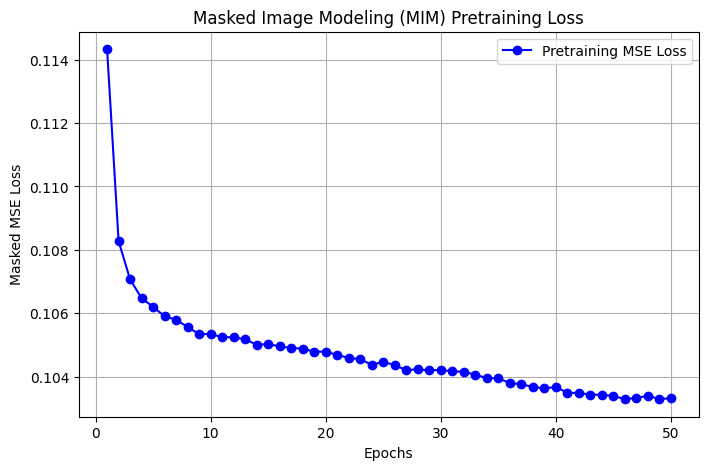

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm.auto import tqdm


# ==========================================
# 2. AUTOENCODER PRETRAINER MODULE
# ==========================================
class L2ViT_MAE_Pretrainer(nn.Module):
    """Wraps the L2ViT backbone with a lightweight convolutional decoder for MIM."""
    def __init__(self, backbone, in_chans=8, embed_dims=[96, 192, 384, 768]):
        super().__init__()
        self.backbone = backbone
        
        # Decoder: Reverses the downsampling of the L2ViT stages
        self.decoder = nn.Sequential(
            # Input from backbone: (Batch, 768, 4, 4)
            nn.ConvTranspose2d(embed_dims[3], embed_dims[2], kernel_size=2, stride=2), 
            nn.BatchNorm2d(embed_dims[2]),
            nn.GELU(),
            # Output: (Batch, 384, 8, 8)
            
            nn.ConvTranspose2d(embed_dims[2], embed_dims[1], kernel_size=2, stride=2),
            nn.BatchNorm2d(embed_dims[1]),
            nn.GELU(),
            # Output: (Batch, 192, 16, 16)
            
            nn.ConvTranspose2d(embed_dims[1], embed_dims[0], kernel_size=2, stride=2),
            nn.BatchNorm2d(embed_dims[0]),
            nn.GELU(),
            # Output: (Batch, 96, 32, 32)
            
            # Reverses the initial ConvStem (4x downsampling)
            nn.ConvTranspose2d(embed_dims[0], in_chans, kernel_size=4, stride=4)
            # Final Output: (Batch, 8, 128, 128)
        )

    def forward(self, x):
        features = self.backbone.forward_features(x)
        reconstructed = self.decoder(features)
        return reconstructed


# ==========================================
# 3. MAE PATCH MASKING UTILITY
# ==========================================
def generate_patch_mask(batch_size, img_size=128, patch_size=16, mask_ratio=0.6, device='cpu'):
    """
    Generates a boolean mask covering `mask_ratio` of the image patches.
    1.0 = Masked (hidden from model), 0.0 = Visible
    """
    num_patches_1d = img_size // patch_size
    num_patches = num_patches_1d ** 2  # e.g., (128/16)^2 = 64 patches
    num_mask = int(num_patches * mask_ratio)
    
    # Generate random noise to shuffle patches
    noise = torch.rand(batch_size, num_patches, device=device)
    ids_shuffle = torch.argsort(noise, dim=1)
    
    # Create the binary mask
    mask = torch.zeros(batch_size, num_patches, device=device)
    for i in range(batch_size):
        mask[i, ids_shuffle[i, :num_mask]] = 1.0  # Set selected patches to 1 (masked)
        
    # Reshape to 2D grid: (B, 8, 8)
    mask = mask.view(batch_size, num_patches_1d, num_patches_1d)
    
    # Scale up to pixel dimensions: (B, 1, 128, 128)
    mask = mask.unsqueeze(1).repeat_interleave(patch_size, dim=2).repeat_interleave(patch_size, dim=3)
    
    return mask

def masked_mse_loss(reconstructed, original, mask):
    """
    Computes MSE ONLY on the pixels that were masked.
    This forces the model to learn physics, not just memorize empty black pixels.
    """
    # Squared error across all pixels
    loss = (reconstructed - original) ** 2
    
    # Zero out the loss for pixels the model was allowed to see
    masked_loss = loss * mask
    
    # Average the loss only over the masked area (mask.sum() * channels)
    return masked_loss.sum() / (mask.sum() * original.shape[1] + 1e-6)


# ==========================================
# 4. THE PRETRAINING LOOP
# +
import matplotlib.pyplot as plt
import os

# ==========================================
# 4. THE PRETRAINING LOOP
# ==========================================
def run_pretraining(train_loader, epochs=60, lr=1e-3, device='cuda'):
    print(f"Initializing L2ViT Pretraining on {device} for {epochs} epochs...")
    
    # 1. Initialize the Backbone
    backbone = L2ViT_Tiny_CERN(in_chans=8, num_classes=2, include_momentum=False)
    
    # 2. Wrap it in the Autoencoder Pretrainer
    model = L2ViT_MAE_Pretrainer(backbone, in_chans=8).to(device)
    
    # 3. Optimizer & Scheduler
    # AdamW with weight decay is crucial for ViT stability
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=0.05)
    
    # Cosine Annealing: Drops LR from 1e-3 down to 1e-5 over the 60 epochs
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)
    
    # To track the loss for plotting
    history_loss =[]
    
    model.train()
    
    for epoch in range(epochs):
        epoch_loss = 0.0
        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
        
        for batch in progress_bar:
            batch = batch.to(device)
            B = batch.shape[0]
            
            # A. Generate the mask (mask 60% of the image)
            mask = generate_patch_mask(B, img_size=128, patch_size=16, mask_ratio=0.6, device=device)
            
            # B. Corrupt the input image
            corrupted_batch = batch * (1.0 - mask)
            
            # C. Forward pass
            optimizer.zero_grad()
            reconstructed = model(corrupted_batch)
            
            # D. Calculate loss ONLY on the hidden patches
            loss = masked_mse_loss(reconstructed, batch, mask)
            
            # E. Backward pass
            loss.backward()
            
            # Gradient clipping (Highly recommended for Linear Attention)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) 
            optimizer.step()
            
            epoch_loss += loss.item()
            progress_bar.set_postfix({'Masked MSE': f"{loss.item():.4f}"})
            
        # Step the learning rate scheduler
        scheduler.step()
        
        avg_loss = epoch_loss / len(train_loader)
        history_loss.append(avg_loss)
        print(f"Epoch {epoch+1}/{epochs} Completed | Avg Loss: {avg_loss:.4f} | LR: {scheduler.get_last_lr()[0]:.6f}")

    print("Pretraining Complete!")
    
    # ==========================================
    # SAVE WEIGHTS
    # ==========================================
    save_path = 'l2vit_tiny_cern_pretrained.pth'
    torch.save(model.backbone.state_dict(), save_path)
    print(f"Pretrained backbone weights saved to {save_path}")
    
    # ==========================================
    # PLOT LOSS CURVE
    # ==========================================
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, epochs + 1), history_loss, marker='o', color='b', label='Pretraining MSE Loss')
    plt.title('Masked Image Modeling (MIM) Pretraining Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Masked MSE Loss')
    plt.grid(True)
    plt.legend()
    
    # Save the plot to disk and display it
    plt.savefig('pretraining_loss_curve.png', bbox_inches='tight')
    plt.show()
    
    return model.backbone


# # ==========================================
# # 5. EXECUTION BLOCK
# # ==========================================
# if __name__ == "__main__":
#     # Ensure CUDA is available
#     device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#     print(f"Using device: {device}")
    
#     # Assuming 'train_loader' is already defined in your notebook
#     # Start the 60-epoch pretraining run!
#     pretrained_backbone = run_pretraining(
#         train_loader=train_loader, 
#         epochs=50, 
#         lr=1e-3, 
#         device=device
#     )

